In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm, binomtest, chi2, jarque_bera
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ============================================================================
# 配置参数
# ============================================================================
START_DATE = '2022-01-01'
END_DATE = '2023-12-31'
INITIAL_PORTFOLIO = 1000000
portfolio_tech = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "TSLA"]
NUM_SIMULATIONS = 10000  # 蒙特卡洛模拟次数

In [3]:
# ============================================================================
# 数据下载函数
# ============================================================================
def download_returns(tickers, start_date, end_date):
    """
    下载股票数据并计算日收益率
    """
    data = yf.download(tickers, start=start_date, end=end_date, progress=False)
    
    if isinstance(data.columns, pd.MultiIndex):
        closes = data['Close']
    else:
        closes = data['Close']
    
    returns = closes.pct_change().dropna()
    return returns

# ============================================================================
# 历史模拟VaR计算函数
# ============================================================================
def historical_simulation_var(returns_series, confidence_level=0.95, initial_investment=1000000):
    """
    历史模拟法计算VaR和CVaR
    """
    sorted_returns = np.sort(returns_series)
    n = len(sorted_returns)
    
    var_percent = np.percentile(returns_series, (1 - confidence_level) * 100)
    exceedances_mask = returns_series < var_percent
    exceedance_count = exceedances_mask.sum()
    
    if exceedance_count > 0:
        cvar_percent = returns_series[exceedances_mask].mean()
    else:
        cvar_percent = var_percent
    
    theoretical_cutoff = int(np.floor((1 - confidence_level) * n))
    
    return {
        'method': 'Historical Simulation',
        'var_percent': var_percent,
        'var_dollar': abs(var_percent) * initial_investment,
        'cvar_percent': cvar_percent,
        'cvar_dollar': abs(cvar_percent) * initial_investment,
        'confidence_level': confidence_level,
        'num_observations': n,
        'theoretical_cutoff': theoretical_cutoff,
        'exceedance_count': exceedance_count,
        'exceedance_rate': exceedance_count / n,
        'worst_return': sorted_returns[0],
        'best_return': sorted_returns[-1],
        'all_sorted_returns': sorted_returns,
        'exceedances': returns_series[exceedances_mask]
    }

# ============================================================================
# 参数法VaR (方差-协方差法)
# ============================================================================
def parametric_var(returns_tech, weights, confidence_level=0.95, initial_investment=1000000):
    """
    参数法（方差-协方差法）计算VaR
    """
    portfolio_returns = returns_tech.dot(weights)
    
    mu_portfolio = portfolio_returns.mean()
    sigma_portfolio = portfolio_returns.std()
    
    z_alpha = norm.ppf(1 - confidence_level)
    var_percent = sigma_portfolio * z_alpha
    var_percent_mean_adjusted = mu_portfolio + sigma_portfolio * z_alpha
    
    phi_z = norm.pdf(z_alpha)
    cvar_percent = sigma_portfolio * (phi_z / (1 - confidence_level))
    
    jb_stat, jb_p = jarque_bera(portfolio_returns)
    
    cov_matrix = returns_tech.cov().values
    marginal_var = z_alpha * (cov_matrix @ weights) / sigma_portfolio
    component_var = weights * marginal_var
    component_var_pct = component_var / var_percent
    
    return {
        'method': 'Parametric (Variance-Covariance)',
        'var_percent': var_percent,
        'var_dollar': abs(var_percent) * initial_investment,
        'var_percent_mean_adjusted': var_percent_mean_adjusted,
        'cvar_percent': cvar_percent,
        'cvar_dollar': abs(cvar_percent) * initial_investment,
        'confidence_level': confidence_level,
        'portfolio_mean': mu_portfolio,
        'portfolio_volatility': sigma_portfolio,
        'z_score': z_alpha,
        'normality_test': {'jarque_bera_p': jb_p, 'is_normal': jb_p > 0.05},
        'marginal_var': marginal_var,
        'component_var': component_var,
        'component_var_pct': component_var_pct,
        'weights': weights.copy()
    }

# ============================================================================
# 蒙特卡洛模拟法
# ============================================================================
def monte_carlo_var(returns_tech, weights, confidence_level=0.95, 
                   initial_investment=1000000, n_simulations=10000):
    """
    蒙特卡洛模拟法计算VaR
    """
    historical_returns = returns_tech.values
    n_days = len(historical_returns)
    
    random_indices = np.random.choice(n_days, size=n_simulations, replace=True)
    simulated_returns = historical_returns[random_indices]
    portfolio_sim_returns = simulated_returns @ weights
    
    var_percent = np.percentile(portfolio_sim_returns, (1 - confidence_level) * 100)
    
    exceedances = portfolio_sim_returns[portfolio_sim_returns < var_percent]
    cvar_percent = exceedances.mean() if len(exceedances) > 0 else var_percent
    
    simulation_stats = {
        'mean_simulated_return': portfolio_sim_returns.mean(),
        'std_simulated_return': portfolio_sim_returns.std(),
        'min_simulated_return': portfolio_sim_returns.min(),
        'max_simulated_return': portfolio_sim_returns.max(),
        'skewness': pd.Series(portfolio_sim_returns).skew(),
        'kurtosis': pd.Series(portfolio_sim_returns).kurtosis(),
        'n_simulations': n_simulations
    }
    
    return {
        'method': 'Monte Carlo Simulation',
        'var_percent': var_percent,
        'var_dollar': abs(var_percent) * initial_investment,
        'cvar_percent': cvar_percent,
        'cvar_dollar': abs(cvar_percent) * initial_investment,
        'confidence_level': confidence_level,
        'simulation_stats': simulation_stats,
        'all_simulated_returns': portfolio_sim_returns
    }

# ============================================================================
# 滚动历史VaR计算函数
# ============================================================================
def rolling_historical_var(returns_series, window=252, confidence_level=0.95):
    """
    计算滚动历史VaR
    """
    rolling_var = returns_series.rolling(window=window).quantile(
        1 - confidence_level,
        interpolation='linear'
    )
    return rolling_var

# ============================================================================
# 不同置信水平VaR比较函数
# ============================================================================
def compare_var_methods(returns_tech, weights, confidence_levels=[0.90, 0.95, 0.99]):
    """
    比较不同置信水平下的VaR
    """
    portfolio_returns = returns_tech.dot(weights)
    
    results = []
    for cl in confidence_levels:
        hs_result = historical_simulation_var(portfolio_returns, confidence_level=cl)
        
        results.append({
            'Confidence': f'{int(cl*100)}%',
            'HS_VaR_%': f'{hs_result["var_percent"]*100:.2f}%',
            'HS_VaR_$': f'${hs_result["var_dollar"]:,.0f}',
            'HS_CVaR_%': f'{hs_result["cvar_percent"]*100:.2f}%',
            'Obs': hs_result['num_observations'],
            'Violations': hs_result['exceedance_count'],
            'Violation_Rate': f'{hs_result["exceedance_rate"]*100:.1f}%'
        })
    
    return pd.DataFrame(results)

# ============================================================================
# 多方法比较函数
# ============================================================================
def compare_all_var_methods(returns_tech, weights, confidence_level=0.95, 
                          initial_investment=1000000):
    """
    比较三种VaR计算方法
    """
    portfolio_returns = returns_tech.dot(weights)
    
    hs_result = historical_simulation_var(portfolio_returns, confidence_level, initial_investment)
    param_result = parametric_var(returns_tech, weights, confidence_level, initial_investment)
    mc_result = monte_carlo_var(returns_tech, weights, confidence_level, initial_investment, NUM_SIMULATIONS)
    
    all_results = {
        'Historical': hs_result,
        'Parametric': param_result,
        'MonteCarlo': mc_result
    }
    
    comparison_data = []
    for method_name, result in all_results.items():
        comparison_data.append({
            'Method': result.get('method', method_name),
            'VaR_%': f"{result['var_percent']*100:.2f}%",
            'VaR_$': f"${result['var_dollar']:,.0f}",
            'CVaR_%': f"{result['cvar_percent']*100:.2f}%",
            'CVaR_$': f"${result['cvar_dollar']:,.0f}",
            'Diff_to_HS_%': f"{(result['var_percent'] - hs_result['var_percent'])*100:+.2f}%"
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    
    return comparison_df, all_results

# ============================================================================
# Kupiec POF检验函数
# ============================================================================
def kupiec_pof_test(portfolio_returns, var_95, confidence_level=0.95):
    """
    Kupiec失败比例检验
    """
    violations = portfolio_returns < var_95
    violation_count = violations.sum()
    total_obs = len(portfolio_returns)
    
    expected_violation_prob = 1 - confidence_level
    expected_violations = total_obs * expected_violation_prob
    
    test_result = binomtest(
        k=violation_count,
        n=total_obs,
        p=expected_violation_prob,
        alternative='two-sided'
    )
    
    actual_rate = violation_count / total_obs if total_obs > 0 else 0
    
    if violation_count == 0:
        LR = -2 * total_obs * np.log(1 - expected_violation_prob)
    elif violation_count == total_obs:
        LR = -2 * total_obs * np.log(expected_violation_prob)
    else:
        LR = 2 * (
            violation_count * np.log(actual_rate / expected_violation_prob) +
            (total_obs - violation_count) * np.log((1-actual_rate) / (1-expected_violation_prob))
        )
    
    LR = max(LR, 0)
    p_value_lr = 1 - chi2.cdf(LR, 1)
    
    return {
        'total_observations': total_obs,
        'var_confidence': f'{confidence_level:.0%}',
        'var_value': var_95,
        'expected_violation_rate': expected_violation_prob,
        'expected_violations': expected_violations,
        'actual_violations': violation_count,
        'actual_violation_rate': actual_rate,
        'binom_p_value': test_result.pvalue,
        'LR_statistic': LR,
        'LR_p_value': p_value_lr,
        'reject_model_at_5pct': test_result.pvalue < 0.05,
        'test_passed': test_result.pvalue >= 0.05
    }

PORTFOLIO RISK ANALYSIS SYSTEM - THREE VAR METHODS
Period: 2022-01-01 to 2023-12-31
Portfolio: AAPL, MSFT, GOOGL, AMZN, META, NVDA, TSLA

1. DOWNLOADING MARKET DATA...
✓ Downloaded 500 trading days of data
  Date range: 2022-01-04 to 2023-12-29

   First 5 days of returns:
Ticker        AAPL    AMZN   GOOGL    META    MSFT    NVDA    TSLA
Date                                                              
2022-01-04 -0.0127 -0.0169 -0.0041 -0.0059 -0.0171 -0.0276 -0.0418
2022-01-05 -0.0266 -0.0189 -0.0459 -0.0367 -0.0384 -0.0576 -0.0535
2022-01-06 -0.0167 -0.0067 -0.0002  0.0256 -0.0079  0.0208 -0.0215
2022-01-07  0.0010 -0.0043 -0.0053 -0.0020  0.0005 -0.0330 -0.0354
2022-01-10  0.0001 -0.0066  0.0121 -0.0112  0.0007  0.0056  0.0303

2. STATISTICAL SUMMARY
------------------------------------------------------------
          Mean     Std     Min     Max    Skew  Kurtosis
Ticker                                                  
AAPL    0.0003  0.0183 -0.0587  0.0890  0.1727    2.0488
A

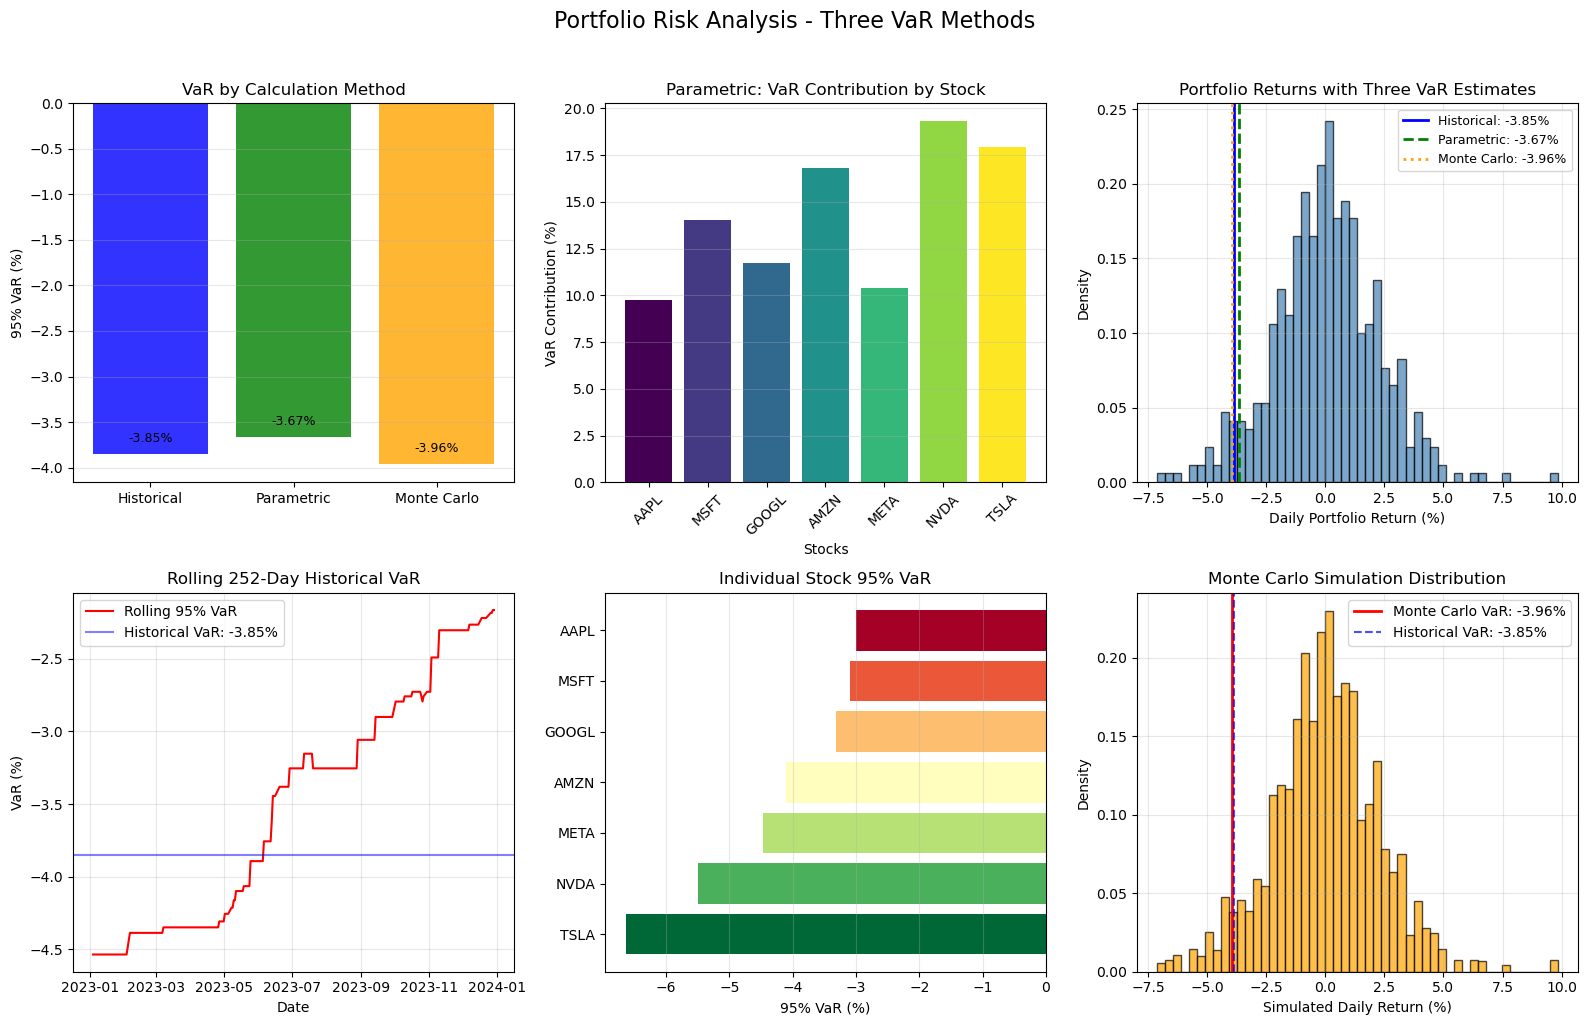


ANALYSIS COMPLETE - THREE VAR METHODS COMPARED


In [4]:
# ============================================================================
# 主执行函数（包含三种方法）
# ============================================================================
def main():
    """主执行函数 - 包含三种VaR方法"""
    
    print("=" * 80)
    print("PORTFOLIO RISK ANALYSIS SYSTEM - THREE VAR METHODS")
    print(f"Period: {START_DATE} to {END_DATE}")
    print(f"Portfolio: {', '.join(portfolio_tech)}")
    print("=" * 80)
    
    # 1. 下载数据
    print("\n1. DOWNLOADING MARKET DATA...")
    returns_tech = download_returns(portfolio_tech, START_DATE, END_DATE)
    print(f"✓ Downloaded {len(returns_tech)} trading days of data")
    print(f"  Date range: {returns_tech.index[0].date()} to {returns_tech.index[-1].date()}")
    
    # 2. 显示数据样本
    print("\n   First 5 days of returns:")
    print(returns_tech.head().round(4))
    
    # 3. 计算统计摘要
    print("\n2. STATISTICAL SUMMARY")
    print("-" * 60)
    summary_df = pd.DataFrame({
        'Mean': returns_tech.mean(),
        'Std': returns_tech.std(),
        'Min': returns_tech.min(),
        'Max': returns_tech.max(),
        'Skew': returns_tech.skew(),
        'Kurtosis': returns_tech.kurtosis()
    }).round(4)
    print(summary_df)
    
    # 4. 构建等权重投资组合
    print("\n3. PORTFOLIO CONSTRUCTION")
    print("-" * 60)
    tech_weights = np.array([1/len(portfolio_tech)] * len(portfolio_tech))
    portfolio_returns = returns_tech.dot(tech_weights)
    
    print(f"Portfolio: Equal weights ({len(portfolio_tech)} stocks)")
    for i, ticker in enumerate(portfolio_tech):
        print(f"  {ticker}: {tech_weights[i]*100:.2f}%")
    print(f"Portfolio returns calculated: {len(portfolio_returns)} days")
    print(f"Portfolio mean return: {portfolio_returns.mean()*100:.4f}% per day")
    print(f"Portfolio volatility: {portfolio_returns.std()*100:.4f}% per day")
    
    # 5. 三种VaR方法比较
    print("\n4. THREE-METHOD VAR COMPARISON (95% Confidence)")
    print("-" * 60)
    
    comparison_df, all_results = compare_all_var_methods(
        returns_tech, tech_weights, confidence_level=0.95,
        initial_investment=INITIAL_PORTFOLIO
    )
    
    print(comparison_df.to_string(index=False))
    
    # 6. 详细分析每种方法
    print("\n5. DETAILED METHOD ANALYSIS")
    print("-" * 60)
    
    # 6.1 参数法详细分析
    print("\nParametric Method Details:")
    param_result = all_results['Parametric']
    print(f"  • Portfolio mean: {param_result['portfolio_mean']*100:.4f}%")
    print(f"  • Portfolio volatility: {param_result['portfolio_volatility']*100:.4f}%")
    print(f"  • Z-score (95%): {param_result['z_score']:.3f}")
    print(f"  • Mean-adjusted VaR: {param_result['var_percent_mean_adjusted']*100:.2f}%")
    
    print(f"\n  Normality Test (Jarque-Bera):")
    jb_p = param_result['normality_test']['jarque_bera_p']
    is_normal = param_result['normality_test']['is_normal']
    print(f"    p-value: {jb_p:.4f}")
    print(f"    Conclusion: {'Normal (fail to reject H0)' if is_normal else 'NOT normal (reject H0 at 5%)'}")
    
    # 6.2 蒙特卡洛法详细分析
    print("\nMonte Carlo Method Details:")
    mc_result = all_results['MonteCarlo']
    stats = mc_result['simulation_stats']
    print(f"  • Simulations: {stats['n_simulations']:,}")
    print(f"  • Mean simulated return: {stats['mean_simulated_return']*100:.4f}%")
    print(f"  • Std simulated return: {stats['std_simulated_return']*100:.4f}%")
    print(f"  • Skewness: {stats['skewness']:.4f}")
    print(f"  • Kurtosis: {stats['kurtosis']:.4f}")
    
    # 7. 风险贡献分析（参数法）
    print("\n6. RISK CONTRIBUTION ANALYSIS (Parametric Method)")
    print("-" * 60)
    
    risk_contrib = []
    for i, ticker in enumerate(portfolio_tech):
        weight_pct = param_result['weights'][i] * 100
        contrib_pct = param_result['component_var_pct'][i] * 100
        risk_contrib.append({
            'Stock': ticker,
            'Weight': f'{weight_pct:.1f}%',
            'VaR Contribution': f'{contrib_pct:.1f}%'
        })
    
    risk_contrib_df = pd.DataFrame(risk_contrib)
    risk_contrib_df = risk_contrib_df.sort_values('VaR Contribution', key=lambda x: x.str.rstrip('%').astype(float), ascending=False)
    print(risk_contrib_df.to_string(index=False))
    
    # 8. 不同置信水平比较（历史模拟法）
    print("\n7. VAR ACROSS CONFIDENCE LEVELS (Historical Simulation)")
    print("-" * 60)
    confidence_comparison = compare_var_methods(returns_tech, tech_weights, [0.90, 0.95, 0.99])
    print(confidence_comparison.to_string(index=False))
    
    # 9. 滚动VaR分析
    print("\n8. ROLLING VAR ANALYSIS (252-day window, Historical)")
    print("-" * 60)
    rolling_var = rolling_historical_var(portfolio_returns, window=252, confidence_level=0.95)
    rolling_var_valid = rolling_var.dropna()
    
    print(f"Calculated {len(rolling_var_valid)} rolling VaR estimates")
    print(f"Rolling VaR statistics:")
    print(f"  • Mean: {rolling_var_valid.mean()*100:.2f}%")
    print(f"  • Std: {rolling_var_valid.std()*100:.2f}%")
    print(f"  • Min: {rolling_var_valid.min()*100:.2f}%")
    print(f"  • Max: {rolling_var_valid.max()*100:.2f}%")
    
    # 10. 个股VaR比较
    print("\n9. INDIVIDUAL STOCK 95% VAR")
    print("-" * 60)
    individual_var = {}
    for ticker in returns_tech.columns:
        var = np.percentile(returns_tech[ticker], 5)
        individual_var[ticker] = var * 100
    
    sorted_var = sorted(individual_var.items(), key=lambda x: x[1])
    print("Stocks ranked by 95% Historical VaR (most risky first):")
    for ticker, var in sorted_var:
        print(f"  {ticker}: {var:.2f}%")
    
    # 11. Kupiec POF检验（使用历史模拟VaR）
    print("\n10. BACKTESTING: KUPIEC POF TEST (Historical Simulation)")
    print("-" * 60)
    
    hs_var = all_results['Historical']['var_percent']
    kupiec_results = kupiec_pof_test(portfolio_returns, hs_var, confidence_level=0.95)
    
    print(f"Test Setup:")
    print(f"  • VaR Confidence Level: {kupiec_results['var_confidence']}")
    print(f"  • Total Observations: {kupiec_results['total_observations']:,} days")
    print(f"  • Expected Violation Rate: {kupiec_results['expected_violation_rate']:.1%}")
    print(f"  • Expected Violations: {kupiec_results['expected_violations']:.1f}")
    
    print(f"\nTest Results:")
    print(f"  • Actual Violations: {kupiec_results['actual_violations']}")
    print(f"  • Actual Violation Rate: {kupiec_results['actual_violation_rate']:.2%}")
    print(f"  • Binomial Test p-value: {kupiec_results['binom_p_value']:.4f}")
    
    if kupiec_results['test_passed']:
        print(f"  ✓ Model validation PASSED (p ≥ 0.05)")
    else:
        print(f"  ✗ Model validation FAILED (p < 0.05)")
    
    # 12. 方法一致性检查
    print("\n11. METHOD CONSISTENCY CHECK")
    print("-" * 60)
    
    print(f"VaR values comparison:")
    hs_var = all_results['Historical']['var_percent'] * 100
    param_var = all_results['Parametric']['var_percent'] * 100
    mc_var = all_results['MonteCarlo']['var_percent'] * 100
    
    print(f"  • Historical Simulation: {hs_var:.2f}% (基准)")
    print(f"  • Parametric: {param_var:.2f}% (差异: {param_var-hs_var:+.2f}%)")
    print(f"  • Monte Carlo: {mc_var:.2f}% (差异: {mc_var-hs_var:+.2f}%)")
    
    # 13. 可视化
    print("\n12. VISUALIZATION")
    print("-" * 60)
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('Portfolio Risk Analysis - Three VaR Methods', fontsize=16, y=1.02)
    
    # 图1: 三种方法VaR比较
    ax1 = axes[0, 0]
    methods = ['Historical', 'Parametric', 'Monte Carlo']
    var_values = [hs_var, param_var, mc_var]
    colors = ['blue', 'green', 'orange']
    bars = ax1.bar(methods, var_values, color=colors, alpha=0.8)
    ax1.set_ylabel('95% VaR (%)')
    ax1.set_title('VaR by Calculation Method')
    ax1.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars, var_values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                f'{val:.2f}%', ha='center', va='bottom', fontsize=9)
    
    # 图2: 参数法风险贡献
    ax2 = axes[0, 1]
    tickers = portfolio_tech
    contributions = param_result['component_var_pct'] * 100
    colors2 = plt.cm.viridis(np.linspace(0, 1, len(tickers)))
    ax2.bar(tickers, contributions, color=colors2)
    ax2.set_xlabel('Stocks')
    ax2.set_ylabel('VaR Contribution (%)')
    ax2.set_title('Parametric: VaR Contribution by Stock')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 图3: 组合收益分布与VaR
    ax3 = axes[0, 2]
    ax3.hist(portfolio_returns * 100, bins=50, alpha=0.7, color='steelblue', 
             edgecolor='black', density=True)
    ax3.axvline(x=hs_var, color='blue', linewidth=2, label=f'Historical: {hs_var:.2f}%')
    ax3.axvline(x=param_var, color='green', linewidth=2, linestyle='--', label=f'Parametric: {param_var:.2f}%')
    ax3.axvline(x=mc_var, color='orange', linewidth=2, linestyle=':', label=f'Monte Carlo: {mc_var:.2f}%')
    ax3.set_xlabel('Daily Portfolio Return (%)')
    ax3.set_ylabel('Density')
    ax3.set_title('Portfolio Returns with Three VaR Estimates')
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)
    
    # 图4: 滚动VaR
    ax4 = axes[1, 0]
    ax4.plot(rolling_var.index, rolling_var.values * 100, color='red', 
             linewidth=1.5, label='Rolling 95% VaR')
    ax4.fill_between(rolling_var.index, rolling_var.values * 100, 
                     rolling_var.values.min() * 100, alpha=0.2, color='red')
    ax4.axhline(y=hs_var, color='blue', linestyle='-', alpha=0.5, label=f'Historical VaR: {hs_var:.2f}%')
    ax4.set_xlabel('Date')
    ax4.set_ylabel('VaR (%)')
    ax4.set_title('Rolling 252-Day Historical VaR')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # 图5: 个股VaR比较
    ax5 = axes[1, 1]
    tickers_sorted = [item[0] for item in sorted_var]
    var_values_sorted = [item[1] for item in sorted_var]
    colors5 = plt.cm.RdYlGn_r(np.linspace(0, 1, len(tickers_sorted)))
    ax5.barh(tickers_sorted, var_values_sorted, color=colors5)
    ax5.axvline(x=0, color='black', linewidth=0.5)
    ax5.set_xlabel('95% VaR (%)')
    ax5.set_title('Individual Stock 95% VaR')
    ax5.grid(True, alpha=0.3, axis='x')
    
    # 图6: 蒙特卡洛模拟分布
    ax6 = axes[1, 2]
    mc_returns = mc_result['all_simulated_returns'] * 100
    ax6.hist(mc_returns, bins=50, alpha=0.7, color='orange', edgecolor='black', density=True)
    ax6.axvline(x=mc_var, color='red', linewidth=2, label=f'Monte Carlo VaR: {mc_var:.2f}%')
    ax6.axvline(x=hs_var, color='blue', linestyle='--', alpha=0.7, linewidth=1.5, label=f'Historical VaR: {hs_var:.2f}%')
    ax6.set_xlabel('Simulated Daily Return (%)')
    ax6.set_ylabel('Density')
    ax6.set_title('Monte Carlo Simulation Distribution')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 80)
    print("ANALYSIS COMPLETE - THREE VAR METHODS COMPARED")
    print("=" * 80)
    
    # 返回所有结果
    return {
        'returns_tech': returns_tech,
        'portfolio_returns': portfolio_returns,
        'weights': tech_weights,
        'comparison_df': comparison_df,
        'all_results': all_results,
        'rolling_var': rolling_var,
        'kupiec_results': kupiec_results
    }

# ============================================================================
# 执行主程序
# ============================================================================
if __name__ == "__main__":
    try:
        results = main()
    except Exception as e:
        print(f"\n错误发生: {str(e)}")
        import traceback
        traceback.print_exc()

META, NVDA, TSLA: over 3%(high volatility)
GOOGL, AMZN: 2%-3%(medium volatility)
AAPL, MSFT: <2%(low volatility)

GOOGL,META,TSLA have negative Skewness: More probability of having deficit
AAPL, AMZN, MSFT, NVDA have positive Skewness: More probability of profit

META has 17.98 Kurtosis
NVDA has 4.58 Kurtosis
AMZN has 3.68 Kurtosis
These stocks have fat tails, especially META, when there are fat tails, it means it has more probability of extrem cases happen.